## **Notebook PC#06**
## Linear and nonlinear dimensionality reduction techniques for data visualization.
**Professor:** Fernando J. Von Zuben <br>
**Cursos:** IA353A / EG453A (FEEC/Unicamp) - 1s2026 <br>
**Aluno(a):** João Lucas M. Ortiz **RA:** 297611 <br>
**Aluno(a):** Daniele Souza Gonçalves **RA:** 248029 <br>


####**This notebook will first show how to visualize data with more than three features using the scatter plot matrix. Then we apply linear and nonlinear dimensionality reduction techniques, more specifically PCA, SOM (only for the MNIST dataset), t-SNE (only for the IRIS dataset) and UMAP, to get 2D/3D representation of our data, and visualize the results with 2D scatter plots and 3D scatter plots. We are going to focus on: (Part 1) The popular IRIS dataset; and (Part 2) The MNIST dataset. This content is based on [this material](https://plotly.com/python/pca-visualization/), [this material](https://plotly.com/python/t-sne-and-umap-projections/), and also [this material](https://medium.com/@weidagang/demystifying-neural-networks-self-organizing-maps-cb3bd406f71b).**

In [1]:
# Loading the main libraries

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import pylab as pl
from sklearn import datasets
from sklearn.decomposition import PCA
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

#**Part 1 - IRIS dataset**

###**Pairwise visualization of all the original dimensions**

In [2]:
df = px.data.iris()
features = ["sepal_width", "sepal_length", "petal_width", "petal_length"]
fig = px.scatter_matrix(df, dimensions=features, color="species", width=900, height=900)
fig.update_layout(margin=dict(l=80, r=30, t=60, b=60))
fig.show()

###**2D projection using the first 2 PCA components**
####Notice the use of normalization on the dataset.

[0.72962445 0.22850762]


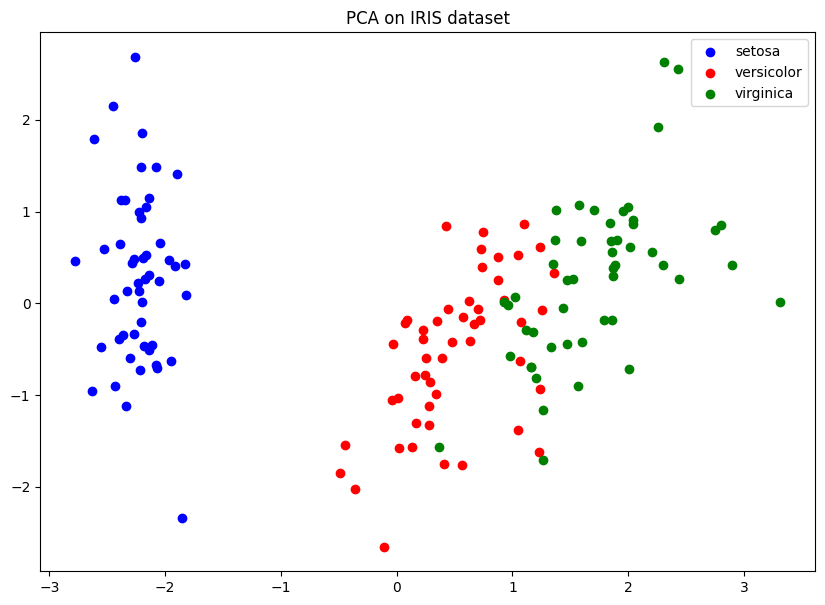

In [3]:
iris = datasets.load_iris()

X = iris.data
X_standard = StandardScaler().fit_transform(X)
y = iris.target
target_names = iris.target_names

pca = PCA(n_components=2)
X_r = pca.fit(X_standard).transform(X_standard)

# Percentage of variance explained for each components
print(pca.explained_variance_ratio_)

pl.figure(figsize=(10, 7))
for c, i, target_name in zip("brg", [0, 1, 2], target_names):
   pl.scatter(X_r[y==i,0], X_r[y==i,1], c=c, label=target_name)
pl.legend()
pl.title('PCA on IRIS dataset')

pl.show()

###**Participation of the original features in the first 2 PCA components**

In [4]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_standard)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

fig = px.scatter(components, x=0, y=1, color=df['species'])

for i, feature in enumerate(features):
    fig.add_annotation(
        ax=0, ay=0,
        axref="x", ayref="y",
        x=loadings[i, 0],
        y=loadings[i, 1],
        showarrow=True,
        arrowsize=2,
        arrowhead=2,
        xanchor="right",
        yanchor="top"
    )
    fig.add_annotation(
        x=loadings[i, 0],
        y=loadings[i, 1],
        ax=0, ay=0,
        xanchor="center",
        yanchor="bottom",
        text=feature,
        yshift=5,
    )
fig.show()

###**Pairwise visualization of all the PCA components**

In [5]:
pca = PCA()
components = pca.fit_transform(X_standard)
labels = {
    str(i): f"PC {i+1} ({var:.1f}%)"
    for i, var in enumerate(pca.explained_variance_ratio_ * 100)
}

fig = px.scatter_matrix(
    components,
    labels=labels,
    dimensions=range(4),
    color=df["species"],
    width=900,
    height=900
)
fig.update_traces(diagonal_visible=False)
fig.update_layout(margin=dict(l=80, r=30, t=60, b=60))
fig.show()


###**Cumulative explained variance of the PCA components**

In [6]:
exp_var_cumul = np.cumsum(pca.explained_variance_ratio_)

px.area(
    x=range(1, exp_var_cumul.shape[0] + 1),
    y=exp_var_cumul,
    labels={"x": "# Components", "y": "Explained Variance"}
)

###**3D projection using the first 3 PCA components**

In [7]:
pca = PCA(n_components=3)
components = pca.fit_transform(X_standard)

total_var = pca.explained_variance_ratio_.sum() * 100

fig = px.scatter_3d(
    components, x=0, y=1, z=2, color=df['species'],
    title=f'Total Explained Variance: {total_var:.2f}%',
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3'}
)
fig.show()

###**2D projection with t-SNE**

In [8]:
tsne = TSNE(n_components=2, random_state=0)
projections = tsne.fit_transform(X_standard)

fig = px.scatter(
    projections, x=0, y=1,
    color=df.species, labels={'color': 'species'}
)
fig.show()

###**3D projection with t-SNE**

In [9]:
tsne = TSNE(n_components=3, random_state=0)
projections = tsne.fit_transform(X_standard)

fig = px.scatter_3d(
    projections, x=0, y=1, z=2,
    color=df.species, labels={'color': 'species'}
)
fig.update_traces(marker_size=8)
fig.show()

###**2D projection with UMAP**

In [10]:
!pip install umap-learn

####**Embora o UMAP requeira uma sintonia cuidadosa de dois de seus hiperparâmetros, [n_neighbors] e [min_dist] (veja [aqui](https://pair-code.github.io/understanding-umap/) ou [aqui](https://umap-learn.readthedocs.io/en/latest/parameters.html)), essa sintonia não será realizada, sendo usados os valores default [n_neighbors = 15] e [min_dist = 0.1] ou outros valores arbitrários, dependendo do caso de estudo e dos objetivos de visualização.**

In [11]:
from umap import UMAP

umap_2d = UMAP(n_components=2, init='random', random_state=0)

proj_2d = umap_2d.fit_transform(X_standard)

fig_2d = px.scatter(
    proj_2d, x=0, y=1,
    color=df.species, labels={'color': 'species'}
)

fig_2d.show()

/Users/danielesouza/miniconda3/envs/ia353_gpu/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


###**3D projection with UMAP**

In [12]:
from umap import UMAP

umap_3d = UMAP(n_components=3, init='random', random_state=0)

proj_3d = umap_3d.fit_transform(X_standard)

fig_3d = px.scatter_3d(
    proj_3d, x=0, y=1, z=2,
    color=df.species, labels={'color': 'species'}
)
fig_3d.update_traces(marker_size=5)

fig_3d.show()

/Users/danielesouza/miniconda3/envs/ia353_gpu/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#**Part 2 - MNIST dataset**

###**2D projection with PCA**

In [13]:
from sklearn.datasets import fetch_openml # Use fetch_openml to load the MNIST dataset

# Load the MNIST dataset using fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Extract the data and target
digits = mnist.data
digits_standard = StandardScaler().fit_transform(digits)
targets = mnist.target

pca = PCA(n_components=2)
projections = pca.fit_transform(digits_standard)

# Percentage of variance explained for each components
print(pca.explained_variance_ratio_)

fig = px.scatter(
    projections, x=0, y=1,
    color=targets.astype(str), labels={'color': 'digit'}
)
fig.update_traces(marker=dict(size=4))
fig.show()

[0.05642719 0.04041226]


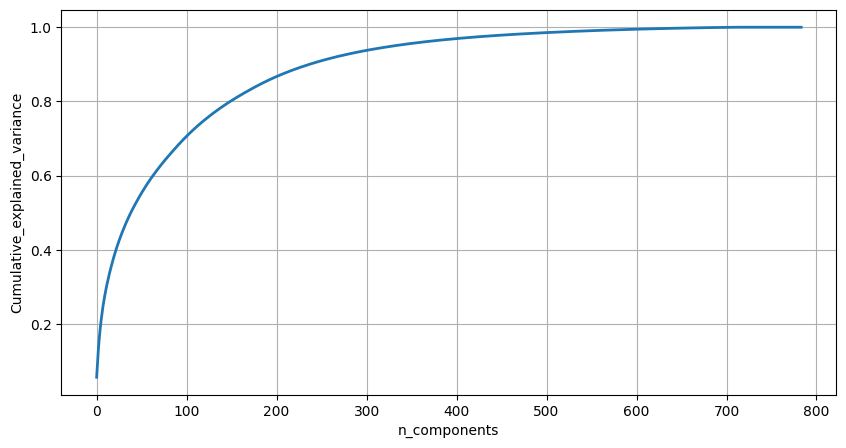

In [14]:
pca = PCA()

pca.n_components = 784
pca_data = pca.fit_transform(digits_standard)
percentage_var_explained = pca.explained_variance_ / np.sum(pca.explained_variance_);
cum_var_explained = np.cumsum(percentage_var_explained)

plt.figure(1, figsize=(10, 5))
plt.clf()
plt.plot(cum_var_explained, linewidth=2)
plt.axis('tight')
plt.grid()
plt.xlabel('n_components')
plt.ylabel('Cumulative_explained_variance')
plt.show()

###**2D projection with the Kohonen Self-Organizing Map**

Loading data...
x_train shape: (1000, 28, 28)
x_train reshaped: (1000, 784)
x_train shape: (1000, 784)
x_train reshaped: (1000, 784)
Starting training...
Training epoch 0/100
Training epoch 10/100
Training epoch 20/100
Training epoch 30/100
Training epoch 40/100
Training epoch 50/100
Training epoch 60/100
Training epoch 70/100
Training epoch 80/100
Training epoch 90/100
Training completed.


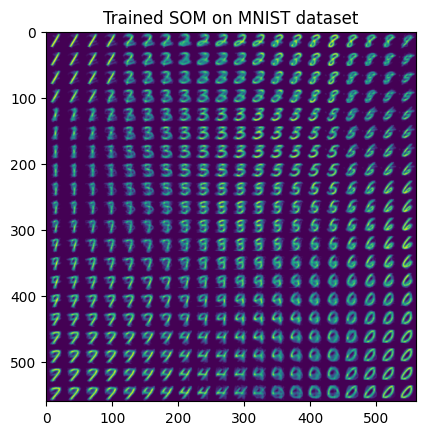

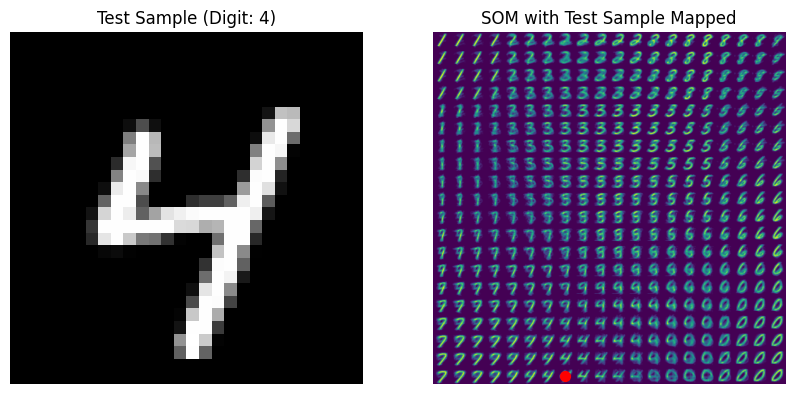

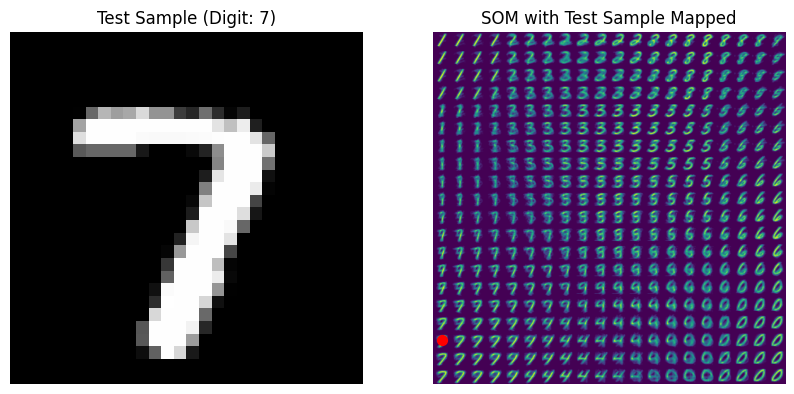

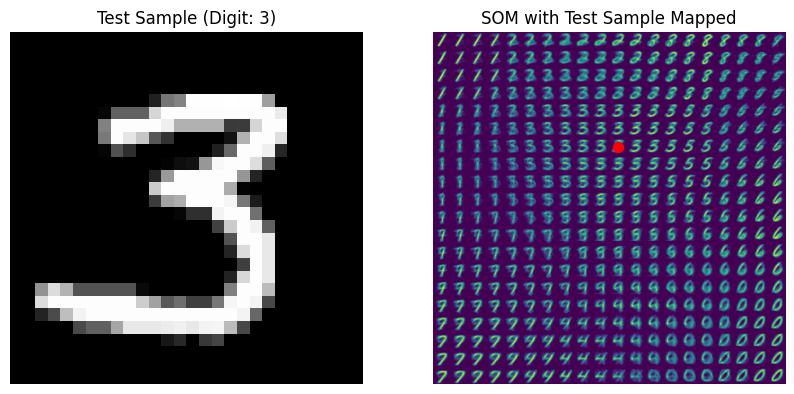

In [15]:
import numpy as np
from keras.datasets import mnist
import matplotlib.pyplot as plt

# Load MNIST data
print('Loading data...')
(x_train, _), (x_test, y_test) = mnist.load_data()
# To speed up the training procedure, only 1000 training instances were considered.
x_train = x_train[:1000]

# Normalize and flatten the data
x_train = x_train.astype('float32') / 255.
print('x_train shape:', x_train.shape)
x_train = x_train.reshape((len(x_train), -1))  # Flatten each 28x28 image into a 784-dimensional vector
print('x_train reshaped:', x_train.shape)

x_test = x_test.astype('float32') / 255.
x_test = x_test.reshape((len(x_test), -1))  # Flatten each 28x28 image into a 784-dimensional vector

# Normalize and flatten the data
x_train = x_train.astype('float32') / 255.
print('x_train shape:', x_train.shape)
x_train = x_train.reshape((len(x_train), -1))  # Flatten each 28x28 image into a 784-dimensional vector
print('x_train reshaped:', x_train.shape)

# Define the model
class SOM:
    def __init__(self, m, n, dim, epochs, alpha, sigma):
        # Initialize the dimensions of the grid, input dimension, learning parameters
        self.m = m  # Number of rows in the SOM
        self.n = n  # Number of columns in the SOM
        self.dim = dim  # Dimension of the input vectors
        self.epochs = epochs  # Number of iterations for training
        self.alpha = alpha  # Initial learning rate
        self.sigma = sigma  # Initial neighborhood radius
        self.weights = np.random.random((m * n, dim))  # Initialize weights randomly

    def find_bmu(self, x):
        # Find the best matching unit for a given vector, x
        bmu_index = np.argmin(np.linalg.norm(self.weights - x, axis=1))
        return np.array([bmu_index // self.n, bmu_index % self.n])

    def update_weights(self, x, bmu, t):
        # Update the weights of the SOM neurons
        learning_rate = self.alpha * np.exp(-t / self.epochs)  # Decay learning rate
        sigma_decay = self.sigma * np.exp(-t / self.epochs)  # Decay neighborhood radius
        for i in range(self.m):
            for j in range(self.n):
                neuron_pos = np.array([i, j])
                distance = np.linalg.norm(neuron_pos - bmu)  # Calculate distance from BMU
                if distance <= sigma_decay:
                    influence = np.exp(-distance**2 / (2 * sigma_decay**2))  # Calculate influence
                    self.weights[i*self.n+j] += learning_rate * influence * (x - self.weights[i*self.n+j])  # Update weights

    def train(self, data):
        # Train the SOM with the given data
        for epoch in range(self.epochs):
            if epoch % 10 == 0:
              print(f"Training epoch {epoch}/{self.epochs}")
            for x in data:
                bmu = self.find_bmu(x)  # Find the BMU for each sample
                self.update_weights(x, bmu, epoch)  # Update weights based on the BMU

    def map_vects(self, data):
        # Map each input vector to the closest neuron in the SOM grid
        bmu_list = []
        for x in data:
            bmu = self.find_bmu(x)
            bmu_list.append(bmu)
        return bmu_list

# SOM parameters
som = SOM(m=20, n=20, dim=784, epochs=100, alpha=0.3, sigma=10.0)

# Training the SOM
print("Starting training...")
som.train(x_train)
print("Training completed.")

# Visualize the trained SOM
plt.imshow(som.weights.reshape(20, 20, 28, 28).transpose(0, 2, 1, 3).reshape(20*28, 20*28))
plt.title('Trained SOM on MNIST dataset')
plt.show()

# Define a function to visualize the test sample and its mapping on SOM
def visualize_test_sample(test_sample, label, mapped_position, som_weights):
    plt.figure(figsize=(10, 5))

    # Display the test sample image
    plt.subplot(1, 2, 1)
    plt.imshow(test_sample.reshape(28, 28), cmap='gray')
    plt.title(f"Test Sample (Digit: {label})")
    plt.axis('off')

    # Display the SOM and mark the position of the test sample
    plt.subplot(1, 2, 2)
    plt.imshow(som_weights.reshape(20, 20, 28, 28).transpose(0, 2, 1, 3).reshape(20*28, 20*28))
    plt.title('SOM with Test Sample Mapped')
    plt.scatter(mapped_position[1]*28 + 14, mapped_position[0]*28 + 14, color='red', s=50)  # Mark the position
    plt.axis('off')

    plt.show()

# Evaluate and visualize a few test samples
test_samples = 3  # Number of test samples to evaluate
for i in range(test_samples):
    test_sample = x_test[i+910]
    test_label = y_test[i+910]
    mapped_position = som.map_vects([test_sample])[0]
    visualize_test_sample(test_sample, test_label, mapped_position, som.weights)

<font color="green">
Atividade (a) <br>
Com base nas imagens geradas a partir da execução da célula acima (particularmente [Trained SOM on MNIST dataset]), explique como se chega ao manifold (espaço de variedades) fornecido pelo mapa de Kohonen 2D após a conclusão do processo de auto-organização.<br>
</font>

Resposta: O mapa de Kohonen começa com 400 neurônios (grid 20×20), cada um com um vetor de pesos de 784 dimensões inicializado aleatoriamente. Nesse momento o grid não tem nenhuma organização em relação aos dados.

A cada amostra apresentada, o algoritmo encontra o neurônio vencedor (BMU), que é aquele cujo vetor de pesos está mais próximo da amostra. Depois, tanto o BMU quanto seus vizinhos no grid são atualizados na direção da amostra, com uma intensidade que decai conforme a distância ao BMU (seguindo uma gaussiana).

O que faz a auto-organização funcionar são dois decaimentos ao longo das épocas: o raio de vizinhança (σ) começa grande, então muitos neurônios se movem juntos forçando uma ordenação global do mapa. Conforme σ vai diminuindo, só os neurônios mais perto do BMU são ajustados, refinando os detalhes locais. A taxa de aprendizado (α) também decai, estabilizando o mapa.

No final do treinamento, neurônios vizinhos no grid acabam representando padrões parecidos no espaço original. Podemos ver isso claramente na imagem "Trained SOM on MNIST dataset": ao visualizar os pesos de cada neurônio como imagens 28×28, notamos que regiões do grid com dígitos "1" ficam próximas de regiões com "7" (que são visualmente parecidos), e o mesmo acontece com "0" e "6". Ou seja, o processo de auto-organização gerou um mapeamento do espaço de 784 dimensões para uma superfície 2D que preserva relações de vizinhança entre os dígitos.

###**2D projection with UMAP**
####Notice that no normalization is performed here, given that the clustering results are ok for the hyperparameters considered.

In [16]:
from sklearn.datasets import fetch_openml # Use fetch_openml to load the MNIST dataset
from umap import UMAP

# Load the MNIST dataset using fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Extract the data and target
digits = mnist.data
targets = mnist.target

projections = UMAP(
    n_neighbors=30,
    min_dist=0.0,
    n_components=2,
).fit_transform(digits)

fig = px.scatter(
    projections, x=0, y=1,
    color=targets.astype(str), labels={'color': 'digit'}
)
fig.update_traces(marker=dict(size=4))
fig.show()

<font color="green">
Atividade (b) <br>
Com base no resultado de projeção 2D apresentado tanto pelo SOM como pela técnica UMAP, exibidos logo acima para a base MNIST, como você defenderia a adoção de um gargalo de 2 dimensões (código 2D) para um autoencoder que deve ser treinado com a base MNIST? Como você sustentaria a afirmação prévia de que esse autoencoder com código 2D tende a apresentar alguns erros de reconstrução para a base MNIST, após o treinamento?<br>
</font>

Resposta: Analisando as projeções 2D do SOM e do UMAP, podemos ver que os dez dígitos formam agrupamentos razoavelmente bem separados, especialmente no caso do UMAP onde os clusters são bastante compactos. Isso nos mostra que os dados do MNIST possuem uma estrutura que pode ser capturada em duas dimensões, o que justifica a adoção de um gargalo 2D para o autoencoder: se técnicas de redução de dimensionalidade já conseguem separar as classes em 2D, um autoencoder, que aprende transformações não-lineares otimizadas para reconstrução,  também deveria conseguir codificar informação relevante com apenas 2 dimensões.

Porém, esse autoencoder com código 2D vai inevitavelmente apresentar erros de reconstrução. O gráfico de variância cumulativa do PCA mostra que duas componentes lineares capturam apenas cerca de 18% da variância total do MNIST. Mesmo com as transformações não-lineares do autoencoder sendo mais expressivas, comprimir 784 dimensões para apenas 2 representa uma perda grande de informação. Além disso, nas próprias projeções 2D podemos notar sobreposição entre alguns clusters, onde dígitos como 4 e 9, ou 3 e 5, compartilham traços visuais e acabam mapeados para regiões próximas. Quando amostras de classes diferentes caem na mesma região do espaço latente 2D, o decoder não consegue distinguir entre elas (por exemplo, um "4" aberto e um "9" com coordenadas parecidas), o que resulta em erros na reconstrução.